# Возьмите один простой набор данных (MNIST, FMNIST, CIFAR-10 и т.д.). Обучите на нём простую модель нейронной сети (не CNN!!!) с применением методов регуляризации и с функцией активации ReLU. Архитектуру задаете сами. Постройте график значения функции потерь от количества эпох, а также график метрик качества от количества эпох


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
epochs = 15
lr = 0.001

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

def train_model(model, optimizer, criterion, epochs):
    history = {'train_loss': [], 'test_acc': []}
    model.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()

        acc = 100. * correct / len(test_loader.dataset)
        history['train_loss'].append(running_loss / len(train_loader))
        history['test_acc'].append(acc)
        print(f"Epoch {epoch+1}: Loss {history['train_loss'][-1]:.4f}, Acc {acc:.2f}%")

    return history

class RegularizedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10)
        )

    def forward(self, x): return self.net(x)

model_reg = RegularizedMLP()
optimizer_reg = optim.Adam(model_reg.parameters(), lr=lr, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

print("Training Model 1 (ReLU + Regularization)...")
history_reg = train_model(model_reg, optimizer_reg, criterion, epochs)

Training Model 1 (ReLU + Regularization)...
Epoch 1: Loss 0.2382, Acc 96.20%
Epoch 2: Loss 0.1141, Acc 96.99%
Epoch 3: Loss 0.0853, Acc 97.89%
Epoch 4: Loss 0.0753, Acc 98.16%
Epoch 5: Loss 0.0614, Acc 97.63%
Epoch 6: Loss 0.0566, Acc 98.10%
Epoch 7: Loss 0.0547, Acc 97.93%
Epoch 8: Loss 0.0491, Acc 97.65%
Epoch 9: Loss 0.0455, Acc 97.95%
Epoch 10: Loss 0.0471, Acc 98.02%
Epoch 11: Loss 0.0404, Acc 98.35%
Epoch 12: Loss 0.0393, Acc 98.37%
Epoch 13: Loss 0.0373, Acc 97.90%
Epoch 14: Loss 0.0353, Acc 97.91%
Epoch 15: Loss 0.0366, Acc 98.35%


# График значения функции потерь от количества эпох и график метрик качества от количества эпох:

Text(0.5, 1.0, 'accuracy - кол-во эпох')

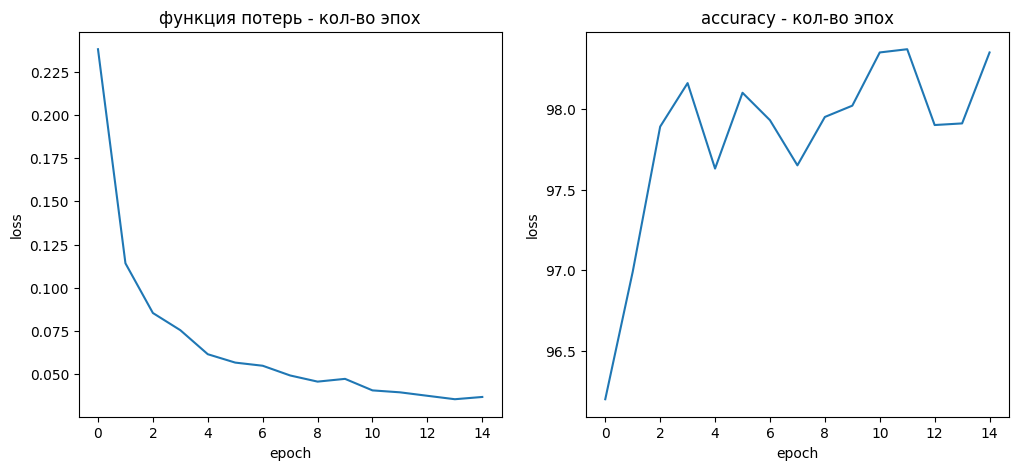

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_reg['train_loss'], label='ReLU + Reg')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("функция потерь - кол-во эпох")

plt.subplot(1, 2, 2)
plt.plot(history_reg['test_acc'], label='ReLU + Reg')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("accuracy - кол-во эпох")

# Уберите из архитектуры регуляризацию. Что стало с результатом? Постройте графики и сравните с оригинальной моделью

In [15]:
class NoRegularizedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.net(x)

model_simple = NoRegularizedMLP()
optimizer_simple = optim.Adam(model_simple.parameters(), lr=lr)

print("\nTraining Model 2 (No Regularization)...")
history_simple = train_model(model_simple, optimizer_simple, criterion, epochs)



Training Model 2 (No Regularization)...
Epoch 1: Loss 0.2012, Acc 96.61%
Epoch 2: Loss 0.0859, Acc 97.37%
Epoch 3: Loss 0.0607, Acc 97.32%
Epoch 4: Loss 0.0459, Acc 97.76%
Epoch 5: Loss 0.0360, Acc 97.93%
Epoch 6: Loss 0.0339, Acc 97.94%
Epoch 7: Loss 0.0267, Acc 97.85%
Epoch 8: Loss 0.0246, Acc 98.09%
Epoch 9: Loss 0.0203, Acc 97.81%
Epoch 10: Loss 0.0206, Acc 97.71%
Epoch 11: Loss 0.0199, Acc 98.10%
Epoch 12: Loss 0.0179, Acc 98.01%
Epoch 13: Loss 0.0166, Acc 97.92%
Epoch 14: Loss 0.0144, Acc 98.36%
Epoch 15: Loss 0.0157, Acc 98.01%


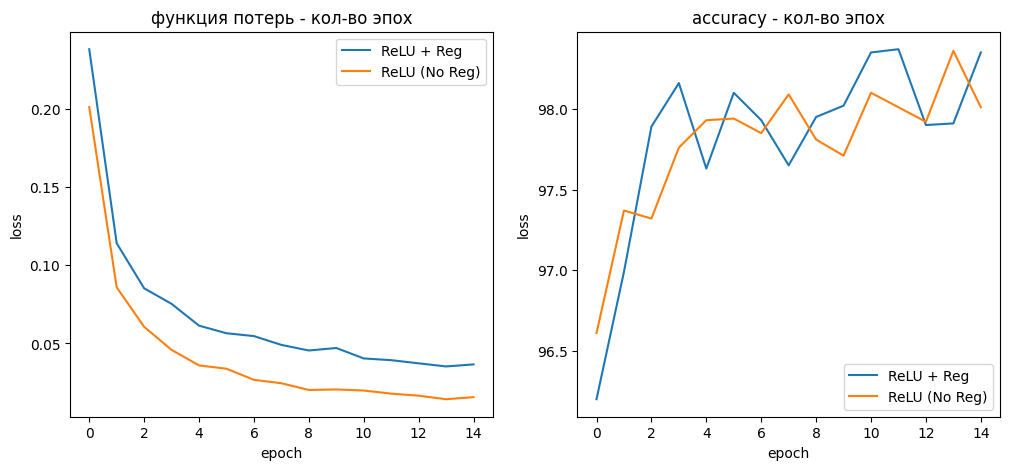

In [16]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_reg['train_loss'], label='ReLU + Reg')
plt.plot(history_simple['train_loss'], label='ReLU (No Reg)')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("функция потерь - кол-во эпох")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_reg['test_acc'], label='ReLU + Reg')
plt.plot(history_simple['test_acc'], label='ReLU (No Reg)')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("accuracy - кол-во эпох")

plt.legend()

кривая ReLU (No Reg) падает быстрее и ниже, чем кривая с регуляризацией

на графике accuracy видно, что оранжевая линия ведет себя более нестабильно по сравнению с синей. к 15 эпохе точность модели без регуляризации получилась ниже, в то время как модель с регуляризацией показывает более стабильный рост точности на тестовых данных.

 то есть, регуляризация делает более плавной обучающую выборку, что делает её предсказания на test данных более надежными

# Замените ReLU на сигмоиду. Что стало с результатом? Если он ухудшился, то почему? Постройте графики и сравните с оригинальной моделью


In [17]:
class SigmoidMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.Sigmoid(),
            nn.Linear(512, 256),
            nn.Sigmoid(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

model_sigmoid = SigmoidMLP()
optimizer_sigmoid = optim.Adam(model_sigmoid.parameters(), lr=lr)

print("\nTraining Model 3 (Sigmoid)...")
history_sigmoid = train_model(model_sigmoid, optimizer_sigmoid, criterion, epochs)


Training Model 3 (Sigmoid)...
Epoch 1: Loss 0.3336, Acc 95.60%
Epoch 2: Loss 0.1119, Acc 96.78%
Epoch 3: Loss 0.0697, Acc 97.22%
Epoch 4: Loss 0.0478, Acc 97.67%
Epoch 5: Loss 0.0333, Acc 97.67%
Epoch 6: Loss 0.0241, Acc 97.87%
Epoch 7: Loss 0.0208, Acc 97.78%
Epoch 8: Loss 0.0177, Acc 97.62%
Epoch 9: Loss 0.0140, Acc 97.85%
Epoch 10: Loss 0.0118, Acc 97.73%
Epoch 11: Loss 0.0151, Acc 97.70%
Epoch 12: Loss 0.0094, Acc 97.86%
Epoch 13: Loss 0.0108, Acc 97.68%
Epoch 14: Loss 0.0106, Acc 97.88%
Epoch 15: Loss 0.0097, Acc 97.64%


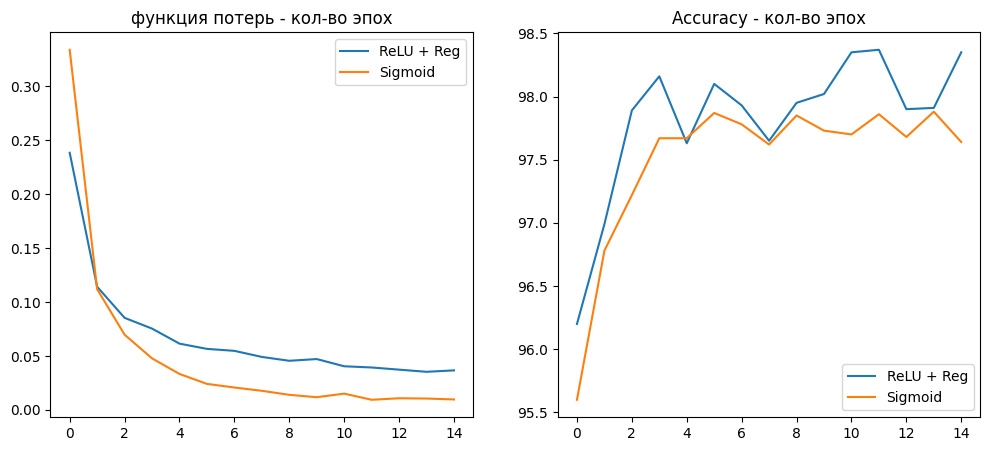

In [18]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_reg['train_loss'], label='ReLU + Reg')
plt.plot(history_sigmoid['train_loss'], label='Sigmoid')
plt.title('функция потерь - кол-во эпох')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_reg['test_acc'], label='ReLU + Reg')
plt.plot(history_sigmoid['test_acc'], label='Sigmoid')
plt.title('Accuracy - кол-во эпох')
plt.legend()
plt.show()

На графике Train Loss видно, что sigmoid начинает с более высокого значения ошибки и сходится медленнее на первых эпохах

Почему результат может ухудшаться (или быть нестабильным)?

- Проблема затухающего градиента
- Насыщение

# Обучите простую CNN на выбранном датасете. Визуализируйте активации на первых слоях сети. Какие закономерности находит модель?

In [19]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(32 * 7 * 7, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model_cnn = SimpleCNN().to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=lr)
print("\nTraining CNN...")
train_model(model_cnn, optimizer_cnn, criterion, epochs=5)


Training CNN...
Epoch 1: Loss 0.1696, Acc 98.33%
Epoch 2: Loss 0.0557, Acc 98.68%
Epoch 3: Loss 0.0413, Acc 98.72%
Epoch 4: Loss 0.0332, Acc 98.81%
Epoch 5: Loss 0.0264, Acc 98.87%


{'train_loss': [0.1696318739455249,
  0.055666543976607315,
  0.04129775832042293,
  0.03322966823058733,
  0.026442084870052222],
 'test_acc': [98.33, 98.68, 98.72, 98.81, 98.87]}

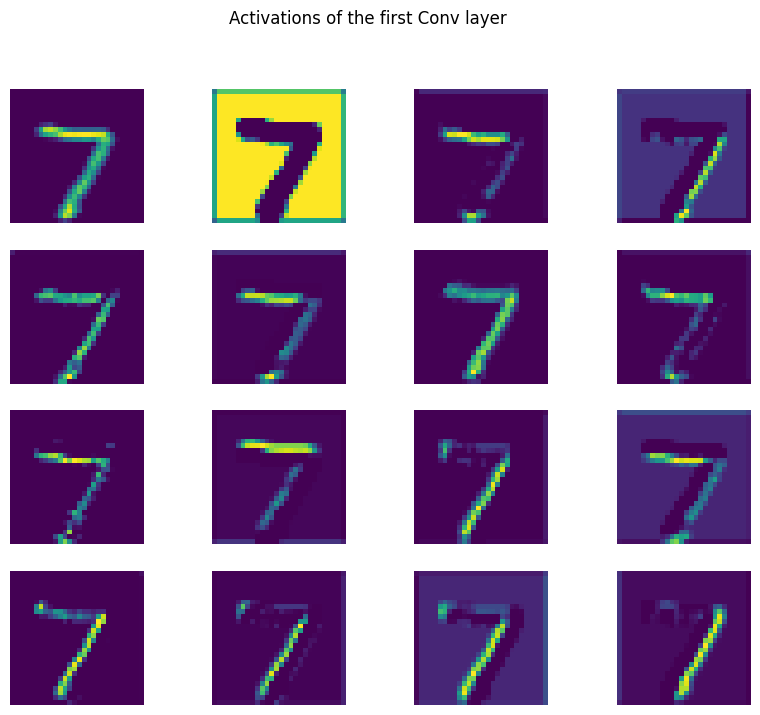

In [20]:
model_cnn.eval()
data, _ = next(iter(test_loader))
data = data[0:1].to(device)

with torch.no_grad():
    activation = model_cnn.relu(model_cnn.conv1(data))

activation = activation.cpu().numpy()
plt.figure(figsize=(10, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(activation[0, i, :, :], cmap='viridis')
    plt.axis('off')
plt.suptitle("Activations of the first Conv layer")
plt.show()

- в некоторых квадратах четко видны только границы цифры. Модель нашла перепады яркости.
- разные фильтры реагируют на разные углы: одни подсвечивают горизонтальную перекладину семерки, другие — наклонную ножку.
- на некоторых изображениях активируются только точки излома или кончики линий
- некоторые активации выглядят как толстая или размытая версия цифры, что помогает модели быть устойчивой к небольшим сдвигам или изменениям толщины линий в рукописном тексте.